In [1]:
# 0. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


## Dataset Overview and Descriptive Stat

In [2]:
# 1. Load datasets
data = pd.read_csv('../data/breast_cancer.csv')


In [3]:
# 2. Basic exploration
print("Shape:")
print(" data set:", data.shape)

print("\nFirst rows of dataset:")
display(data.head())

print("\nDescriptive statistics:")
display(data.describe())

# Data type
print("\nData types:")
print(data.dtypes)


Shape:
 data set: (512, 32)

First rows of dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,M,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,...,19.07,30.88,123.40,1138.0,0.1464,0.1871,0.29140,0.16090,0.3029,0.08216
1,2,B,11.50,18.45,73.28,407.4,0.09345,0.05991,0.02638,0.02069,...,12.97,22.46,83.12,508.9,0.1183,0.1049,0.08105,0.06544,0.2740,NaN
2,3,M,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,...,16.84,27.66,112.00,876.5,0.1131,0.1924,0.23220,0.11190,0.2809,0.06287
3,4,M,18.82,21.97,123.70,1110.0,0.10180,0.13890,0.15940,0.08744,...,22.66,30.93,145.30,1603.0,0.1390,0.3463,0.39120,0.17080,0.3007,0.08314
4,5,B,12.95,16.02,83.14,513.7,0.10050,0.07943,0.06155,0.03370,...,13.74,19.93,88.81,585.4,0.1483,NaN,0.22410,0.10560,0.3380,0.09584



Descriptive statistics:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,512.000000,505.00000,507.000000,507.000000,508.000000,506.000000,511.000000,502.000000,504.000000,507.000000,...,507.000000,510.000000,505.000000,505.000000,507.000000,503.000000,508.000000,501.000000,509.000000,505.000000
mean,256.500000,14.17355,19.364142,92.231933,657.616929,0.096168,0.103624,0.088031,0.048893,0.181339,...,16.313700,25.754941,107.876515,889.918812,0.131889,0.251145,0.272561,0.114208,0.289997,0.083879
std,147.945936,3.55379,4.314426,24.584304,357.110765,0.014208,0.053119,0.080220,0.039362,0.027501,...,4.885558,6.152356,34.106884,579.834235,0.023130,0.155159,0.209698,0.065945,0.061297,0.018044
min,1.000000,6.98100,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,128.750000,11.71000,16.195000,75.235000,420.175000,0.085843,0.064130,0.028835,0.019983,0.162100,...,12.980000,21.222500,84.160000,514.000000,0.114750,0.143700,0.116625,0.064130,0.250600,0.071470
50%,256.500000,13.40000,18.890000,86.340000,548.750000,0.095200,0.091820,0.059640,0.033455,0.179200,...,14.980000,25.445000,97.900000,686.600000,0.131100,0.211800,0.225450,0.099100,0.281800,0.079930
75%,384.250000,15.78000,21.830000,104.200000,784.150000,0.105250,0.129850,0.128650,0.073460,0.195700,...,19.125000,30.015000,127.100000,1124.000000,0.146000,0.328050,0.385300,0.161300,0.317600,0.092030
max,512.000000,28.11000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Data types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavi

we have appreciated with count that there are many samples that are nan, let´s find after deleteing columns that are unnecessary anf after spliting the target from the other features

In [4]:
# 2.5 delete id column
data.drop(columns=['id'], inplace=True)

In [5]:
# 3. Check for duplicates
print("Duplicate rows in all features:", data.duplicated().sum())

Duplicate rows in all features: 0


In [6]:
# 3.2 Check if any row is fully NaN
fully_nan_rows = data.index[data.isna().all(axis=1)]
print("Rows with all values missing:", fully_nan_rows.tolist())


Rows with all values missing: []


In [7]:
# 3.3 Check for missing values 
print("Missing values per column:")
display(data.isnull().sum())

Missing values per column:


diagnosis                   0
radius_mean                 7
texture_mean                5
perimeter_mean              5
area_mean                   4
smoothness_mean             6
compactness_mean            1
concavity_mean             10
concave points_mean         8
symmetry_mean               5
fractal_dimension_mean      3
radius_se                   2
texture_se                  7
perimeter_se                1
area_se                     3
smoothness_se               6
compactness_se              4
concavity_se                2
concave points_se           4
symmetry_se                 5
fractal_dimension_se        5
radius_worst                5
texture_worst               2
perimeter_worst             7
area_worst                  7
smoothness_worst            5
compactness_worst           9
concavity_worst             4
concave points_worst       11
symmetry_worst              3
fractal_dimension_worst     7
dtype: int64

In [8]:
# 4. Convert diagnosis column to binary (M=0, B=1)
data['diagnosis'] = data['diagnosis'].map({'M': 0, 'B': 1})


In [9]:
# 4.2 Check if the dataset is balanced

# Count the number of benign (B=1) and malignant (M=0) cases
class_distribution = data['diagnosis'].value_counts()

# Calculate percentages
class_percentage = data['diagnosis'].value_counts(normalize=True) * 100
benign_count = class_distribution[1]
malignant_count = class_distribution[0]

# Display the results
print(f"\nBenign cases (B): {benign_count} ({class_percentage[1]:.2f}%)")
print(f"Malignant cases (M): {malignant_count} ({class_percentage[0]:.2f}%)")

# Determine if the dataset is balanced (commonly 40–60% split)
if min(class_percentage) > 40:
    print("\nThe dataset is reasonably balanced.")
else:
    imbalance_ratio = max(class_distribution) / min(class_distribution)
    print(f"\nThe dataset is imbalanced with a ratio of {imbalance_ratio:.2f}:1")



Benign cases (B): 321 (62.70%)
Malignant cases (M): 191 (37.30%)

The dataset is imbalanced with a ratio of 1.68:1


In [10]:
# 5. Outlier detection using IQR

def count_outliers(df, columns):
    outliers = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        outliers[col] = outlier_count
    return pd.Series(outliers).sort_values(ascending=False)

# Exclude the target column from outlier detection
feature_cols = data.columns.drop('diagnosis')

print("Variables with most outliers:")
display(count_outliers(data, feature_cols))


Variables with most outliers:


area_se                    60
perimeter_se               35
radius_se                  33
concavity_se               26
symmetry_se                25
fractal_dimension_se       25
smoothness_se              24
area_mean                  24
compactness_se             24
area_worst                 23
fractal_dimension_worst    21
symmetry_worst             20
concave points_se          19
texture_se                 18
compactness_worst          18
concavity_mean             17
compactness_mean           15
symmetry_mean              14
radius_mean                14
perimeter_mean             13
perimeter_worst            13
fractal_dimension_mean     12
radius_worst               12
concavity_worst            11
concave points_mean         9
texture_mean                7
smoothness_mean             5
texture_worst               4
smoothness_worst            3
concave points_worst        0
dtype: int64

In [11]:
# 6. Saving data with binary class and without id

data.to_csv("../data/breast_cancer_cleaned.csv", index=False)

## Feature Assessment and Visualization:

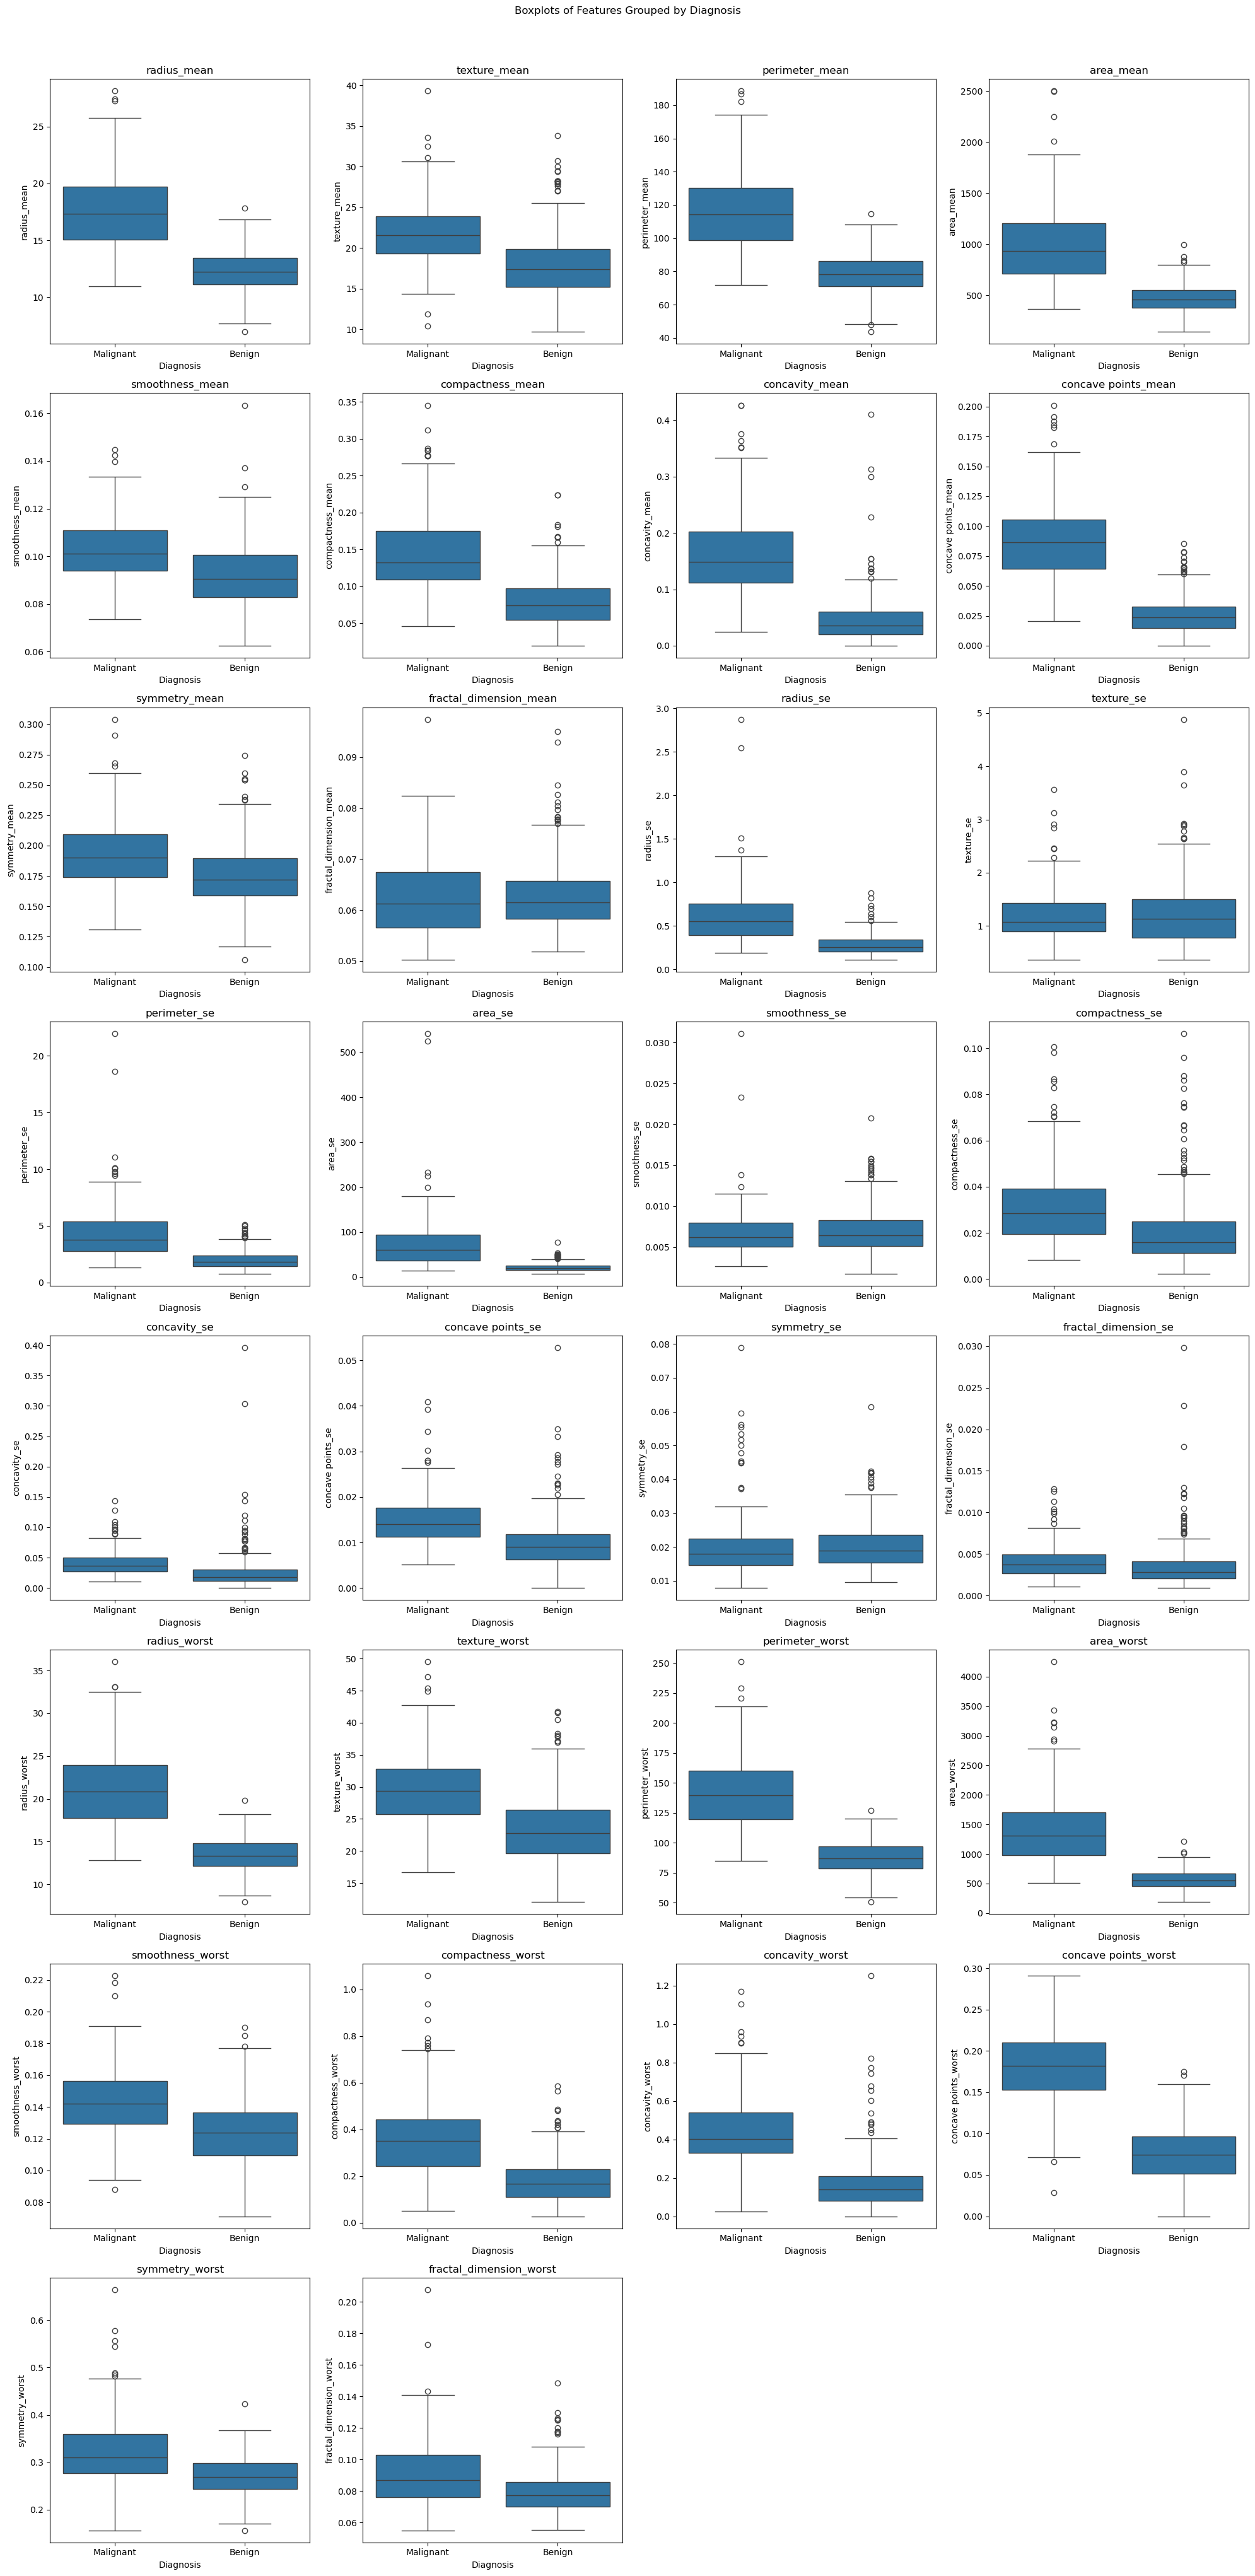

In [12]:
# 1. Boxplots for each feature grouped by class (with readable labels)

import matplotlib.pyplot as plt
import seaborn as sns

# Create a copy with readable labels
data_plot = data.copy()
data_plot['diagnosis_label'] = data_plot['diagnosis'].map({0: 'Malignant', 1: 'Benign'})



# Plot
plt.figure(figsize=(20, 40))
for i, col in enumerate(feature_cols, 1): # feature_cols has already been defined in '6. Outlier detection'
    plt.subplot(8, 4, i)
    sns.boxplot(x='diagnosis_label', y=col, data=data_plot)
    plt.title(col)
    plt.xlabel('Diagnosis')
    plt.ylabel(col)
    plt.tight_layout()

plt.suptitle('Boxplots of Features Grouped by Diagnosis', y=1.02)
plt.show()


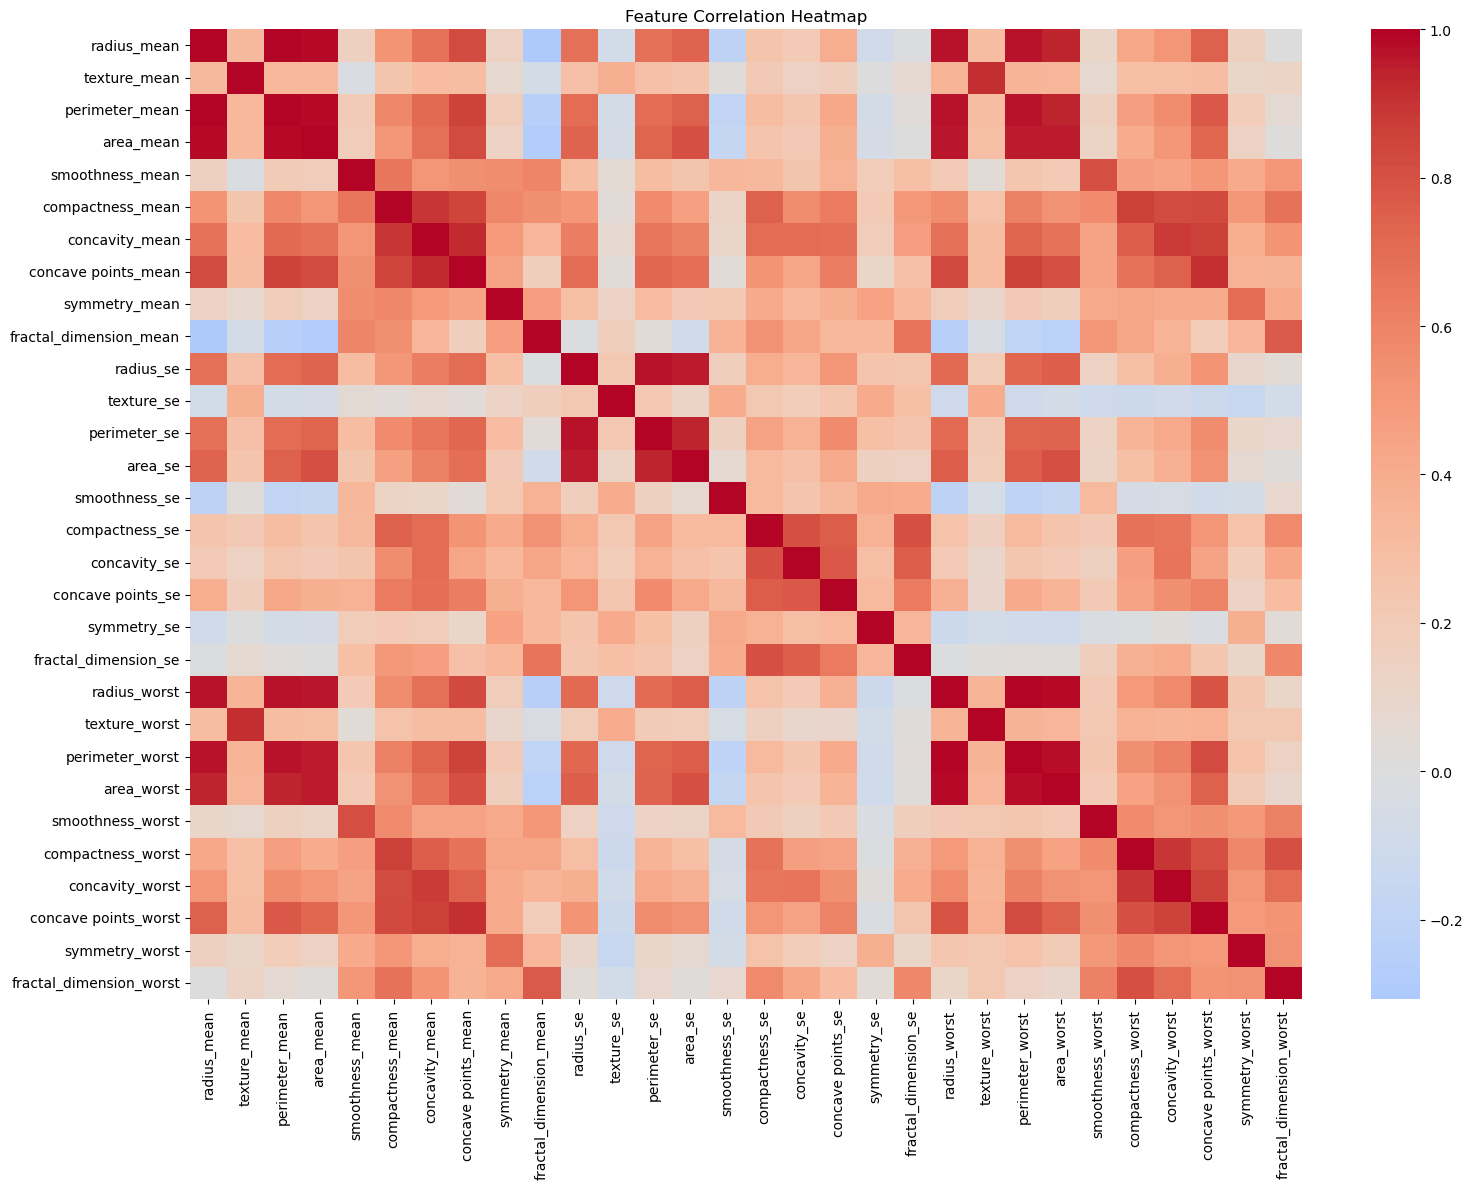

In [13]:
# 2. Heatmap of correlations between features (excluding target)

# Compute correlation matrix
corr_matrix = data[feature_cols].corr()    # feature_cols has already been defined in '6. Outlier detection'

# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1627/1141241995.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="viridis")


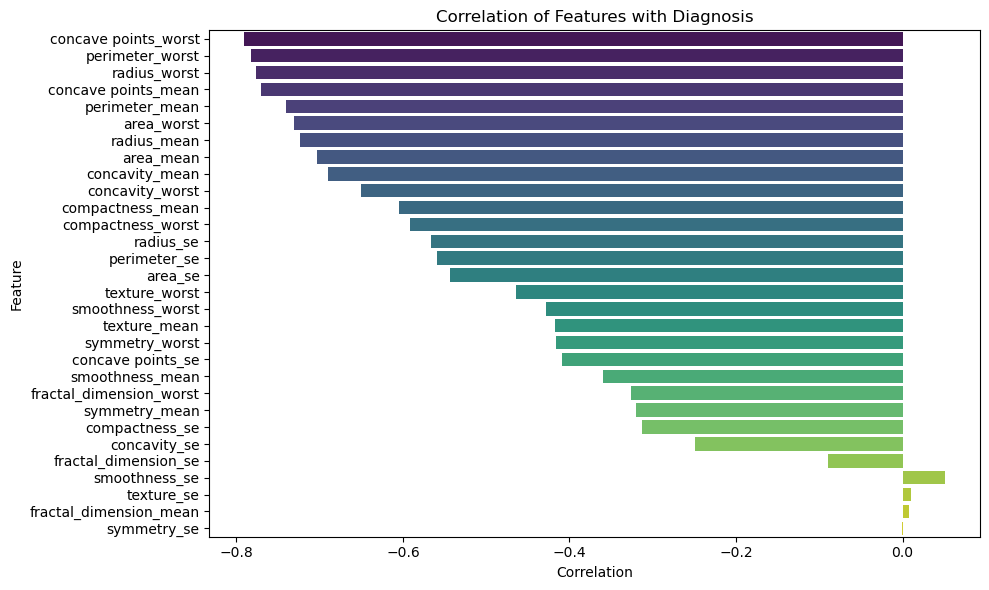

In [14]:
# 3. Correlation of features with the diagnosis (target)

# Calculate correlation between each feature and the target
corr_with_target = data[list(feature_cols) + ['diagnosis']].corr()['diagnosis'].drop('diagnosis').sort_values(key=abs, ascending=False)


# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette="viridis")
plt.title('Correlation of Features with Diagnosis')
plt.xlabel('Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



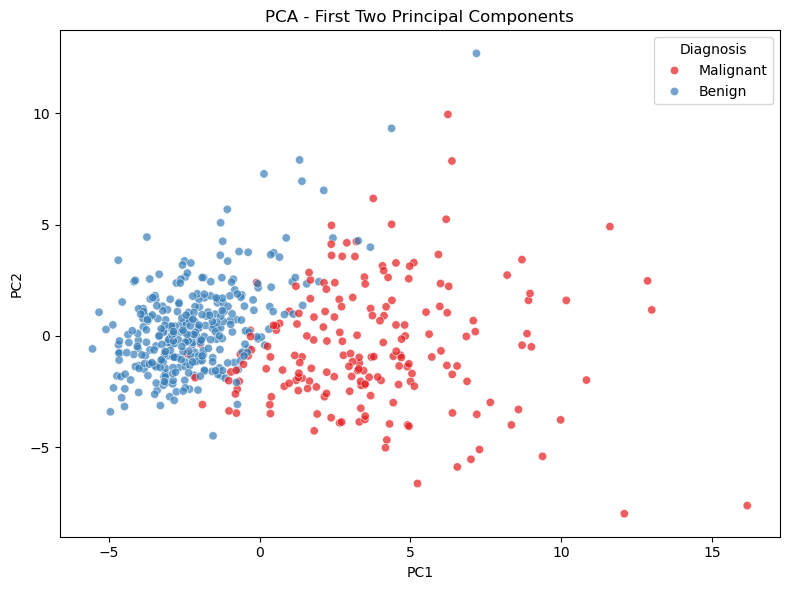

Explained variance ratio (first 2 components): [0.44105853 0.18329152]


In [15]:
# 4. PCA for dimensionality reduction and visualization (exploratory only)

# Create a temporary copy for PCA with missing values imputed using median
data_pca = data.copy()
data_pca[feature_cols] = data_pca[feature_cols].fillna(data_pca[feature_cols].median())

# Add readable diagnosis labels (needed for coloring the plot)
data_pca['diagnosis_label'] = data_pca['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_pca[feature_cols])

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA projection colored by diagnosis
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data_pca['diagnosis_label'], palette='Set1', alpha=0.7)
plt.title('PCA - First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

# Explained variance
print("Explained variance ratio (first 2 components):", pca.explained_variance_ratio_)


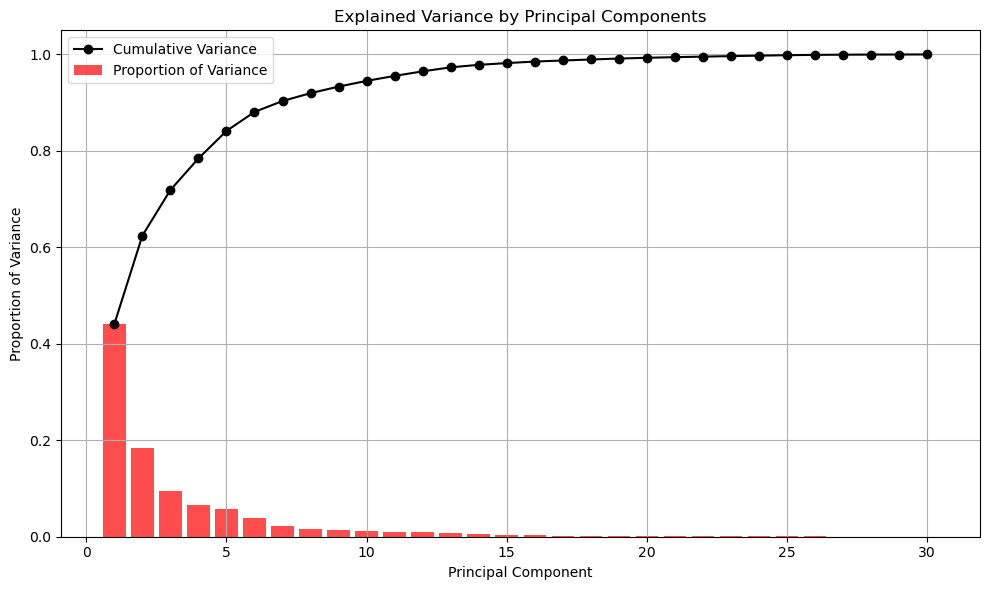

In [16]:
# 4.2 Run PCA using all components
pca_all = PCA(n_components=len(feature_cols))
pca_all.fit(X_scaled)

# Get explained variance for each principal component
explained_var = pca_all.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Plot the explained variance
plt.figure(figsize=(10, 6))
components = np.arange(1, len(explained_var) + 1)

# Red bars: variance explained by each component
plt.bar(components, explained_var, alpha=0.7, color='red', label='Proportion of Variance')

# Black line: cumulative variance
plt.plot(components, cumulative_var, marker='o', color='black', label='Cumulative Variance')

plt.ylabel('Proportion of Variance')
plt.xlabel('Principal Component')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

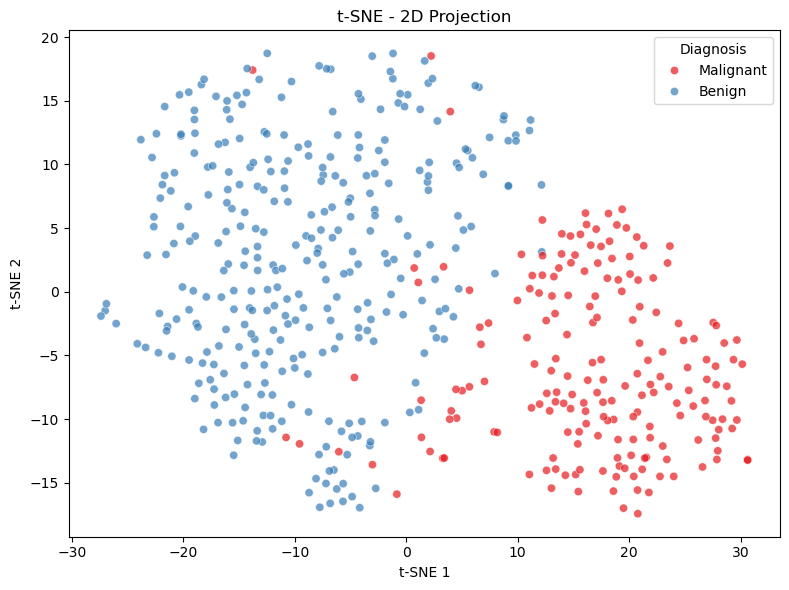

In [17]:
# 5. t-SNE projection for non linear relations

# Reuse the same imputed and scaled data
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

# Plot t-SNE projection
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=data_pca['diagnosis_label'], palette='Set1', alpha=0.7)
plt.title('t-SNE - 2D Projection')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()
